In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [ ]:
data = pd.read_csv('/content/Coca-Cola_stock_history.csv')

In [ ]:
data.reset_index(inplace=True)

In [ ]:
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         15311 non-null  int64  
 1   Date          15311 non-null  object 
 2   Open          15311 non-null  float64
 3   High          15311 non-null  float64
 4   Low           15311 non-null  float64
 5   Close         15311 non-null  float64
 6   Volume        15311 non-null  int64  
 7   Dividends     15311 non-null  float64
 8   Stock Splits  15311 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 1.1+ MB
None
   index        Date      Open      High       Low     Close   Volume  \
0      0  1962-01-02  0.050016  0.051378  0.050016  0.050016   806400   
1      1  1962-01-03  0.049273  0.049273  0.048159  0.048902  1574400   
2      2  1962-01-04  0.049026  0.049645  0.049026  0.049273   844800   
3      3  1962-01-05  0.049273  0.049892  0.048035  0.048159

In [ ]:
print(data.isnull().sum())

# Fill missing numerical values with the column mean
data.fillna(method='ffill', inplace=True) # Forward fill for stock data continuity
data.fillna(0, inplace=True) # Replace remaining missing dividends/splits with 0

# Confirm no missing values remain
print(data.isnull().sum())

index           0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
index           0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


<ipython-input-5-382ee4e6294f>:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True) # Forward fill for stock data continuity


In [ ]:
# Add Moving Averages
data['MA_20'] = data['Close'].rolling(window=20).mean()
data['MA_50'] = data['Close'].rolling(window=50).mean()

# Add Daily Returns
data['Daily_Return'] = data['Close'].pct_change()

# Add Volatility (standard deviation of returns over a rolling window)
data['Volatility'] = data['Daily_Return'].rolling(window=20).std()

# Drop rows with NA due to rolling calculations
data.dropna(inplace=True)

print(data.head())

    index        Date      Open      High       Low     Close   Volume  \
49     49  1962-03-13  0.046416  0.046789  0.046416  0.046789  1344000   
50     50  1962-03-14  0.046789  0.046976  0.046603  0.046852  1689600   
51     51  1962-03-15  0.046852  0.046976  0.046603  0.046603   883200   
52     52  1962-03-16  0.046603  0.046789  0.046603  0.046603   768000   
53     53  1962-03-19  0.046603  0.047101  0.046603  0.046852   921600   

    Dividends  Stock Splits     MA_20     MA_50  Daily_Return  Volatility  
49   0.001563             0  0.045788  0.046525      0.015962    0.013223  
50   0.000000             0  0.045797  0.046461      0.001334    0.013226  
51   0.000000             0  0.045836  0.046415     -0.005320    0.012546  
52   0.000000             0  0.045889  0.046362      0.000000    0.012460  
53   0.000000             0  0.045953  0.046336      0.005348    0.012491  


In [ ]:
# Summary statistics
print(data.describe())

              index          Open          High           Low         Close  \
count  15262.000000  15262.000000  15262.000000  15262.000000  15262.000000   
mean    7679.500000     11.850660     11.944785     11.754847     11.853194   
std     4405.904239     15.035006     15.142659     14.924814     15.035590   
min       49.000000      0.037154      0.037279      0.034890      0.037028   
25%     3864.250000      0.239461      0.241549      0.237297      0.239432   
50%     7679.500000      4.959658      5.012348      4.918166      4.959969   
75%    11494.750000     17.425250     17.663839     17.230594     17.456363   
max    15310.000000     66.037933     66.235058     64.776308     65.259270   

             Volume     Dividends  Stock Splits         MA_20         MA_50  \
count  1.526200e+04  15262.000000  15262.000000  15262.000000  15262.000000   
mean   9.164087e+06      0.001683      0.001114     11.818108     11.760960   
std    7.957132e+06      0.021336      0.049226    

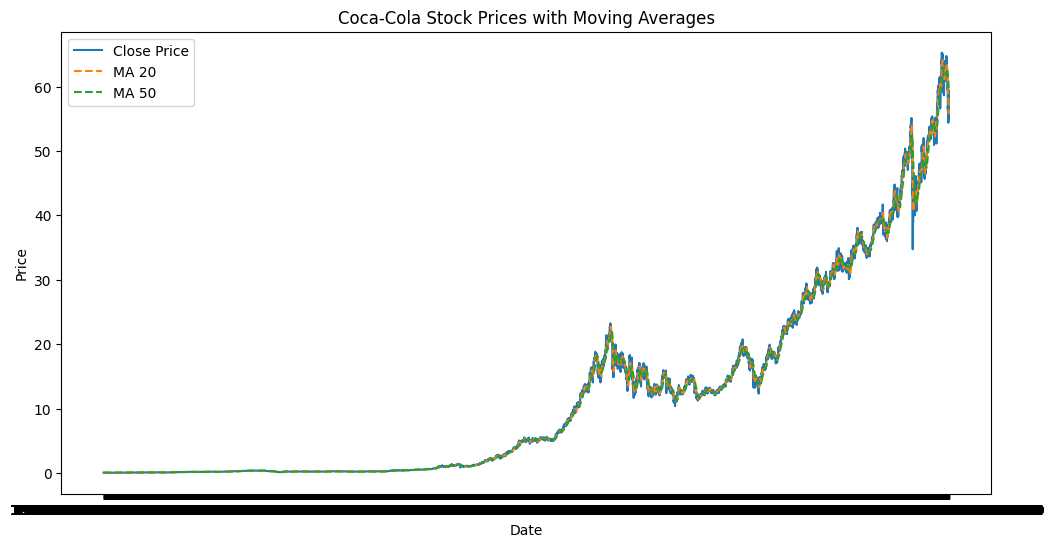

In [ ]:
# Line plot for stock prices
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.plot(data['Date'], data['MA_20'], label='MA 20',
linestyle='--')
plt.plot(data['Date'], data['MA_50'], label='MA 50',
linestyle='--')
plt.title('Coca-Cola Stock Prices with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
# Features and target
features = ['Open', 'High', 'Low', 'Volume', 'Dividends',
'Stock Splits', 'MA_20', 'MA_50', 'Daily_Return', 'Volatility']
target = 'Close'

X = data[features]

y = data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42, shuffle=False)

In [ ]:
from sklearn.metrics import mean_absolute_error
# Initialize the model
model = RandomForestRegressor(n_estimators=100,
random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 327.97684970501126
Mean Absolute Error: 14.669394395869661


In [ ]:
ticker = 'KO'

In [ ]:
# Using the 'Close' column for prediction
data = data.filter(['Close'])
dataset = data.values

In [ ]:
# Scaling the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [ ]:
# Splitting the data into training and testing sets
train_size = int(len(dataset) * 0.8)
train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size - 60:, :]

# Preparing the data for LSTM model
def create_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

In [ ]:
# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train, y_train, batch_size=1, epochs=1)

12149/12149 ━━━━━━━━━━━━━━━━━━━━ 309s 25ms/step - loss: 1.6306e-04


In [ ]:
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

rmse = np.sqrt(np.mean(((lstm_predictions - y_test) ** 2)))
print('LSTM Model RMSE:', rmse)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
LSTM Model RMSE: 34.456789478865446


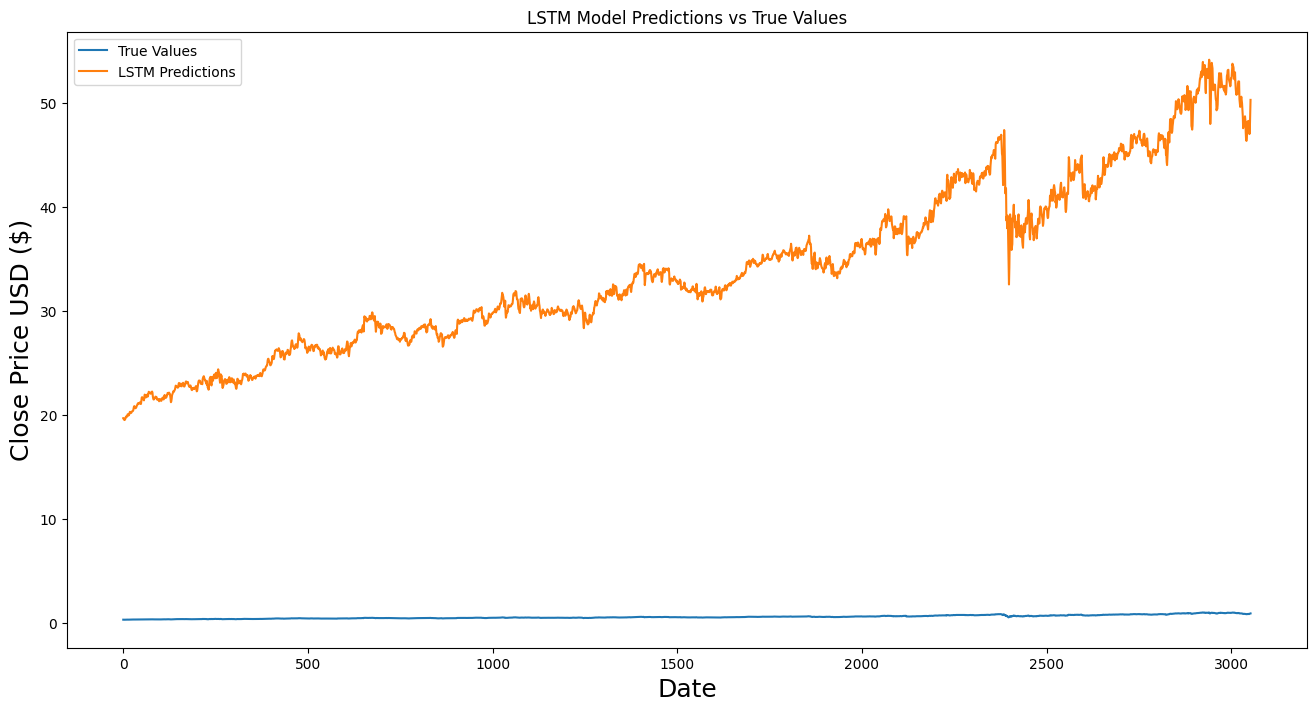

In [ ]:
# Visualizing the Results for LSTM
plt.figure(figsize=(16,8))
plt.title('LSTM Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(lstm_predictions, label='LSTM Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Preparing the data for SVR model
X = data.index.values.reshape(-1, 1)
y = data['Close'].values

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the SVR Model
svr_model = SVR(kernel='rbf', C=1e3, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)


SVR(C=1000.0, gamma=0.1)

In [ ]:
# Predicting and evaluating the SVR model
svr_predictions = svr_model.predict(X_test_scaled)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
print('SVR Model RMSE:', svr_rmse)

SVR Model RMSE: 30.88278092153784


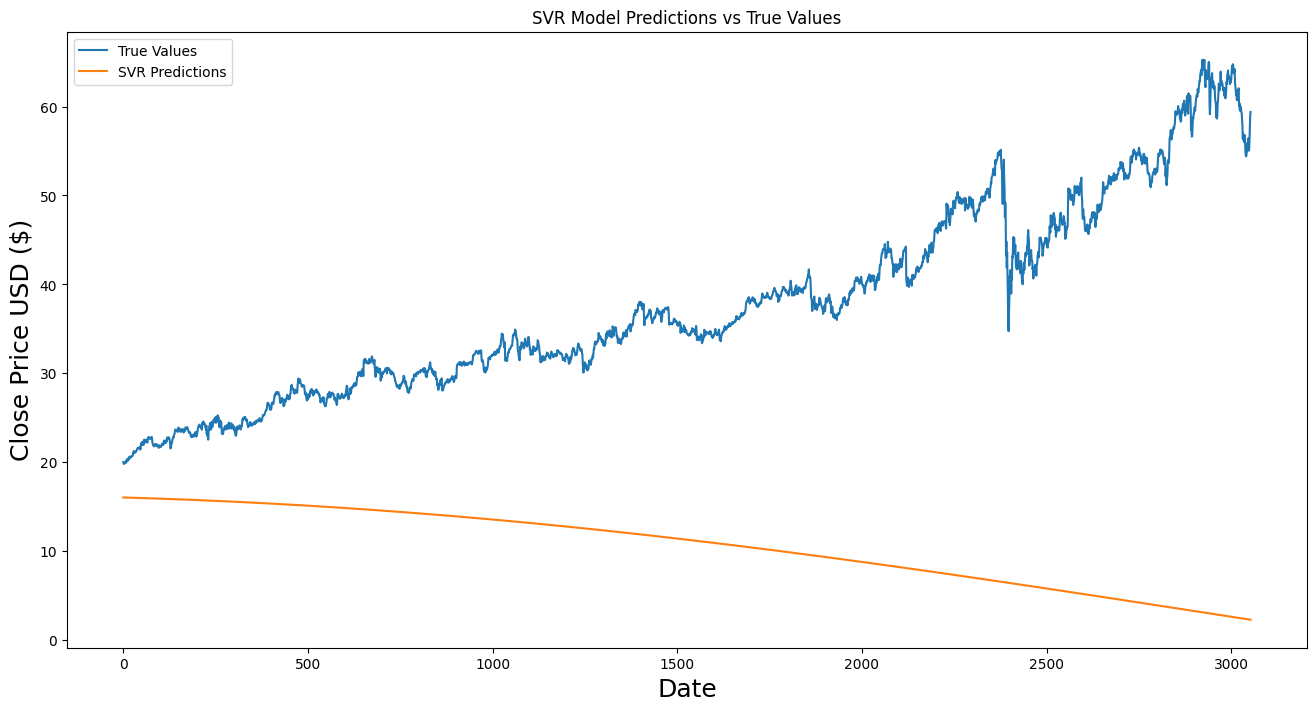

In [ ]:
# Visualizing the Results for SVR
plt.figure(figsize=(16,8))
plt.title('SVR Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(svr_predictions, label='SVR Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()


In [ ]:
# Preparing the data for SGD Regressor model
X = data.index.values.reshape(-1, 1)
y = data['Close'].values

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Training the SGD Regressor Model
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)
sgd_model.fit(X_train_scaled, y_train)

SGDRegressor()

In [ ]:
# Predicting and evaluating the SGD model
sgd_predictions = sgd_model.predict(X_test_scaled)
sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_predictions))
print('SGD Model RMSE:', sgd_rmse)

SGD Model RMSE: 22.055893411922074


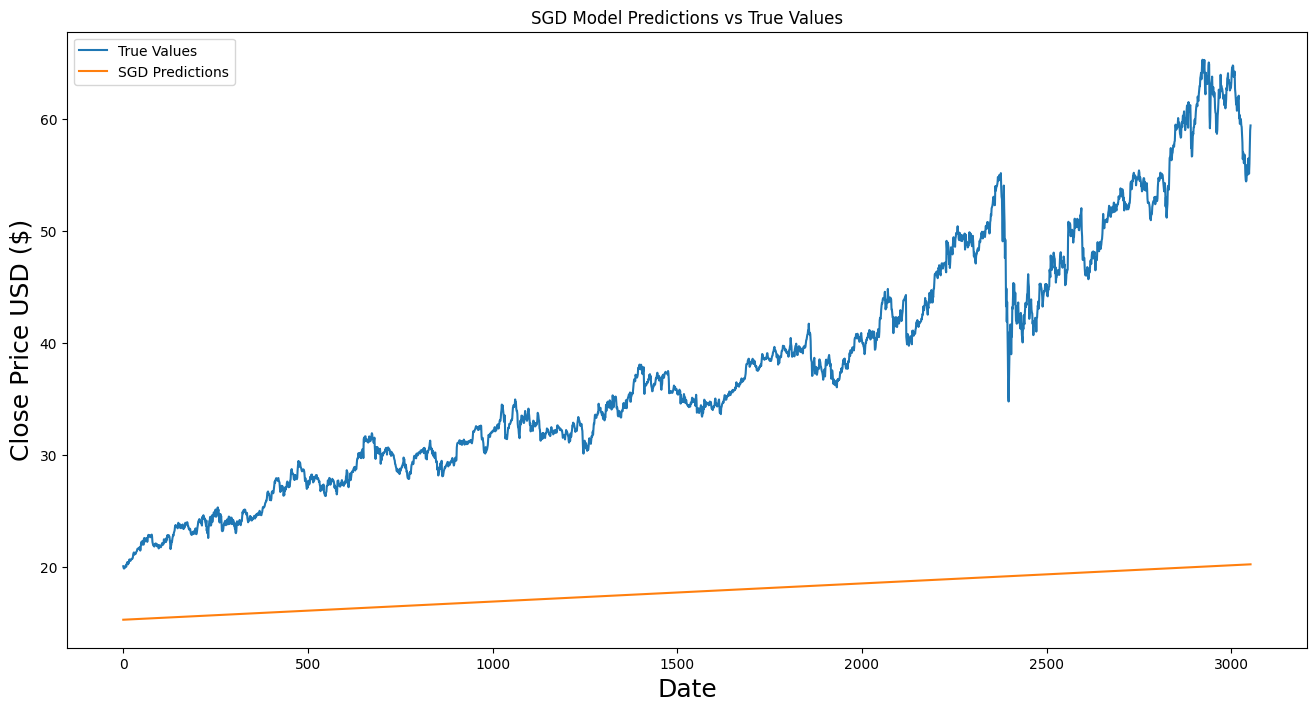

In [ ]:
# Visualizing the Results for SGD
plt.figure(figsize=(16,8))
plt.title('SGD Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(sgd_predictions, label='SGD Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Preparing the data for Decision Tree Regressor model
X = data.index.values.reshape(-1, 1)
y = data['Close'].values

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Training the Decision Tree Regressor Model
dtr_model = DecisionTreeRegressor()
dtr_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
# Predicting and evaluating the Decision Tree model
dtr_predictions = dtr_model.predict(X_test)
dtr_rmse = np.sqrt(mean_squared_error(y_test, dtr_predictions))
print('Decision Tree Model RMSE:', dtr_rmse)

Decision Tree Model RMSE: 20.651434076407366


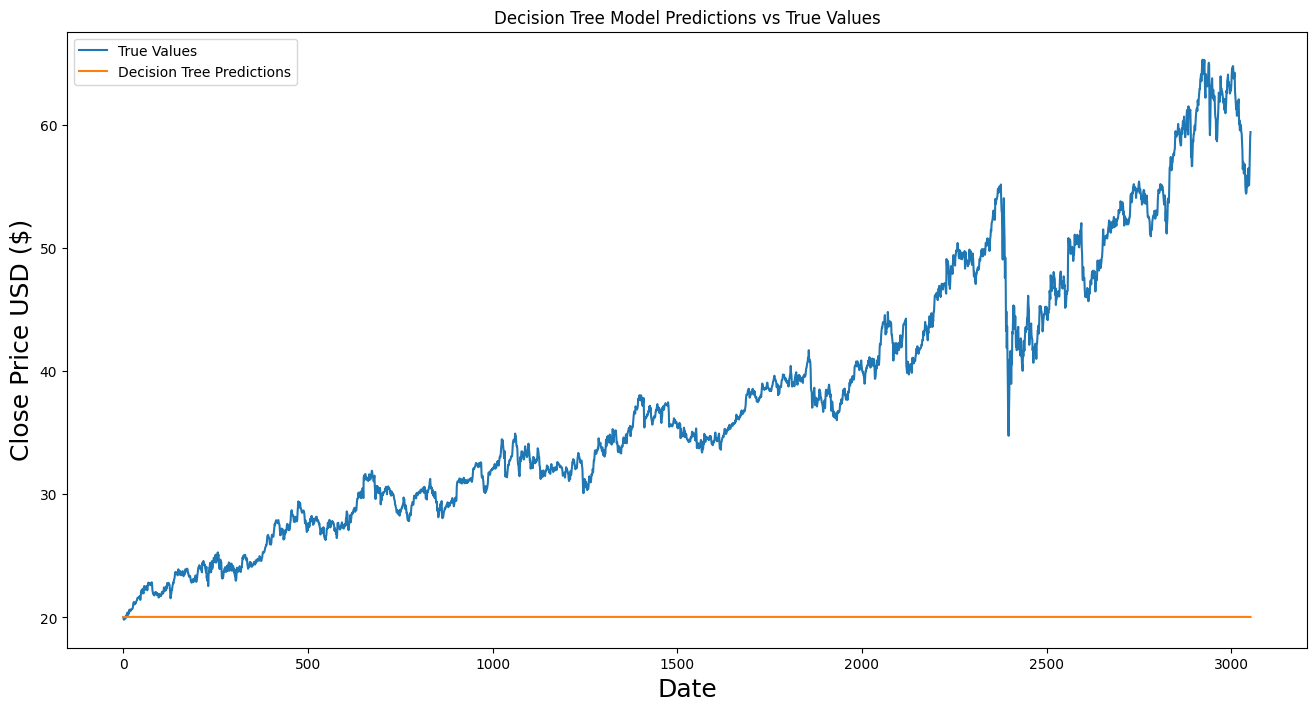

In [ ]:
# Visualizing the Results for Decision Tree
plt.figure(figsize=(16,8))
plt.title('Decision Tree Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(dtr_predictions, label='Decision Tree Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Preparing the data for Random Forest Regressor model
X = data.index.values.reshape(-1, 1)
y = data['Close'].values

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Training the Random Forest Regressor Model
rfr_model = RandomForestRegressor(n_estimators=100)
rfr_model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
# Predicting and evaluating the Random Forest model
rfr_predictions = rfr_model.predict(X_test)
rfr_rmse = np.sqrt(mean_squared_error(y_test, rfr_predictions))
print('Random Forest Model RMSE:', rfr_rmse)

Random Forest Model RMSE: 20.706072657565237


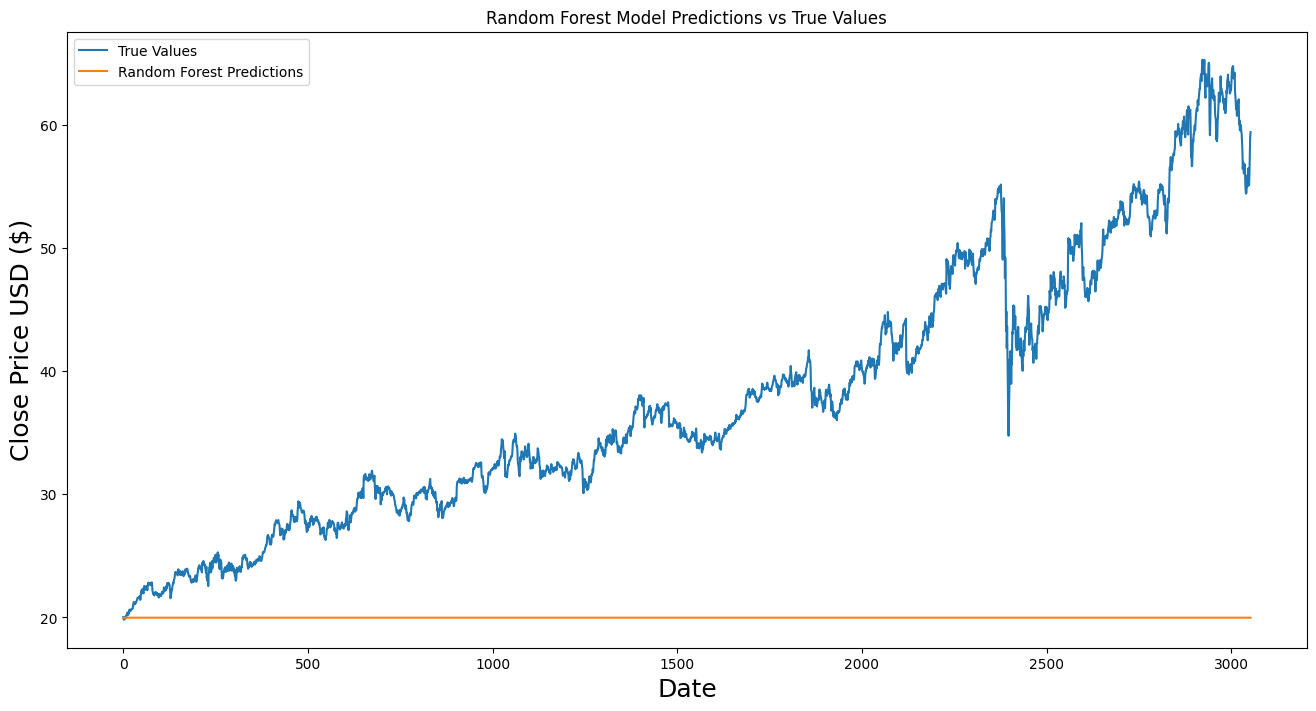

In [ ]:
# Visualizing the Results for Random Forest
plt.figure(figsize=(16,8))
plt.title('Random Forest Model Predictions vs True Values')
plt.plot(y_test, label='True Values')
plt.plot(rfr_predictions, label='Random Forest Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend()
plt.show()